# Elastic Disks SimVP

Train a CNN-only SimVP forecaster on Elastic Disks sequences.


In [1]:
from pathlib import Path
import subprocess
import sys

GITHUB_REPO_URL = "https://github.com/jordanshivers/generative-video-forecasting.git"
REPO_DIRNAME = "generative-video-forecasting"
INSTALL_REQUIREMENTS = True
RETRAIN = True


def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src" / "video_forecasting").exists():
            return candidate
    if Path("/content").exists():
        repo_root = Path("/content") / REPO_DIRNAME
        if not repo_root.exists():
            subprocess.run(["git", "clone", GITHUB_REPO_URL, str(repo_root)], check=True)
        return repo_root
    raise RuntimeError("Could not find the generative-video-forecasting repository root.")


REPO_ROOT = find_repo_root()
if INSTALL_REQUIREMENTS and Path("/content").exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_ROOT / "requirements.txt")], check=True)

sys.path.insert(0, str(REPO_ROOT / "src"))
print(f"Repo root: {REPO_ROOT}")


Repo root: /content/generative-video-forecasting


In [2]:
import torch
from torch.utils.data import DataLoader

from video_forecasting.models.simvp import SimVP, SimVPSequenceDataset
from video_forecasting.runtime import get_data_dir, get_device, get_output_dir, set_seed
from video_forecasting.presets import batch_size_for_device, get_preset
from video_forecasting.training import count_parameters, evaluate_simvp, train_simvp_epoch
from video_forecasting.visualization import (
    display_video,
    generate_simvp_rollout_movie,
    plot_training_curves,
    set_output_dir,
    visualize_simvp_predictions,
)

set_seed(42)
device = get_device(prefer_mps=True)
DATA_DIR = get_data_dir(REPO_ROOT)
OUTPUT_DIR = get_output_dir("train_elastic_disks_simvp", REPO_ROOT)
set_output_dir(OUTPUT_DIR)
print(f"Device: {device}")
print(f"Output dir: {OUTPUT_DIR}")


Device: cuda
Output dir: /content/generative-video-forecasting/outputs/train_elastic_disks_simvp


## Dataset

SimVP predicts a block of future frames from an equally sized context window. 


In [3]:
from video_forecasting.datasets.elastic_disks import ElasticDisksDataset

dataset_cfg = get_preset("elastic_disks")
simvp_cfg = get_preset("simvp")
num_sequences = dataset_cfg["num_sequences"]
max_sequences = dataset_cfg["max_sequences"]
sequence_length = dataset_cfg["sequence_length"]
context_frames = simvp_cfg["context_frames"]
pred_frames = simvp_cfg["pred_frames"]
batch_size = batch_size_for_device(device, simvp_cfg["batch_size"])

train_base = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=True,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=dataset_cfg["frame_separation"],
    seed=42,
    max_sequences=max_sequences,
)
test_base = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=False,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=dataset_cfg["frame_separation"],
    seed=42,
    max_sequences=max_sequences,
)
train_dataset = SimVPSequenceDataset(train_base, context_frames=context_frames, pred_frames=pred_frames, stride=1)
test_dataset = SimVPSequenceDataset(test_base, context_frames=context_frames, pred_frames=pred_frames, stride=1)

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)
print(f"Train windows: {len(train_dataset)}; test windows: {len(test_dataset)}")



Dataset initialized:
  Dataset: elastic_disks
  Split: train
  Total sequences: 2000
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 5
  Total pairs: 54000
  Image size: 64x64
  Channels: 1 (grayscale)

Dataset initialized:
  Dataset: elastic_disks
  Split: test
  Total sequences: 500
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 5
  Total pairs: 13500
  Image size: 64x64
  Channels: 1 (grayscale)
Train windows: 26000; test windows: 6500


## Model


In [4]:
model = SimVP(
    shape_in=(context_frames, 1, 64, 64),
    hid_s=simvp_cfg["hid_s"],
    hid_t=simvp_cfg["hid_t"],
    num_spatial_layers=simvp_cfg["num_spatial_layers"],
    num_temporal_layers=simvp_cfg["num_temporal_layers"],
    kernels=(3, 5, 7, 11),
    groups=8,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
checkpoint_path = OUTPUT_DIR / "simvp_elastic_disks_model.pt"
print(f"Parameters: {count_parameters(model):,}")


Parameters: 2,176,833


## Train


In [5]:
# num_epochs = simvp_cfg["num_epochs"]
num_epochs = 20

train_losses = []
val_losses = []

if checkpoint_path.exists() and not RETRAIN:
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"Loaded checkpoint: {checkpoint_path}")
else:
    for epoch in range(num_epochs):
        train_loss = train_simvp_epoch(model, train_loader, optimizer, device)
        val_loss = evaluate_simvp(model, test_loader, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}: train={train_loss:.5f}, val={val_loss:.5f}")
    torch.save(model.state_dict(), checkpoint_path)
    plot_training_curves(
        train_losses,
        val_losses,
        output_path=OUTPUT_DIR / "simvp_training_curves.png",
        title="SimVP Training Curves",
    )
    print(f"Saved checkpoint: {checkpoint_path}")


Evaluating SimVP: 100%|██████████| 51/51 [00:07<00:00,  6.89it/s]


Epoch 1/20: train=0.07030, val=0.06287


Evaluating SimVP: 100%|██████████| 51/51 [00:07<00:00,  6.89it/s]


Epoch 2/20: train=0.04925, val=0.03977


Evaluating SimVP: 100%|██████████| 51/51 [00:07<00:00,  6.68it/s]


...

Epoch 18/20: train=0.01362, val=0.02055


Evaluating SimVP: 100%|██████████| 51/51 [00:09<00:00,  5.37it/s]


Epoch 19/20: train=0.01314, val=0.02141


Evaluating SimVP: 100%|██████████| 51/51 [00:09<00:00,  5.26it/s]


Epoch 20/20: train=0.01278, val=0.02097
Saved checkpoint: /content/generative-video-forecasting/outputs/train_elastic_disks_simvp/simvp_elastic_disks_model.pt


## Evaluate

Create prediction figures, generate an autoregressive rollout movie, and display it inline.


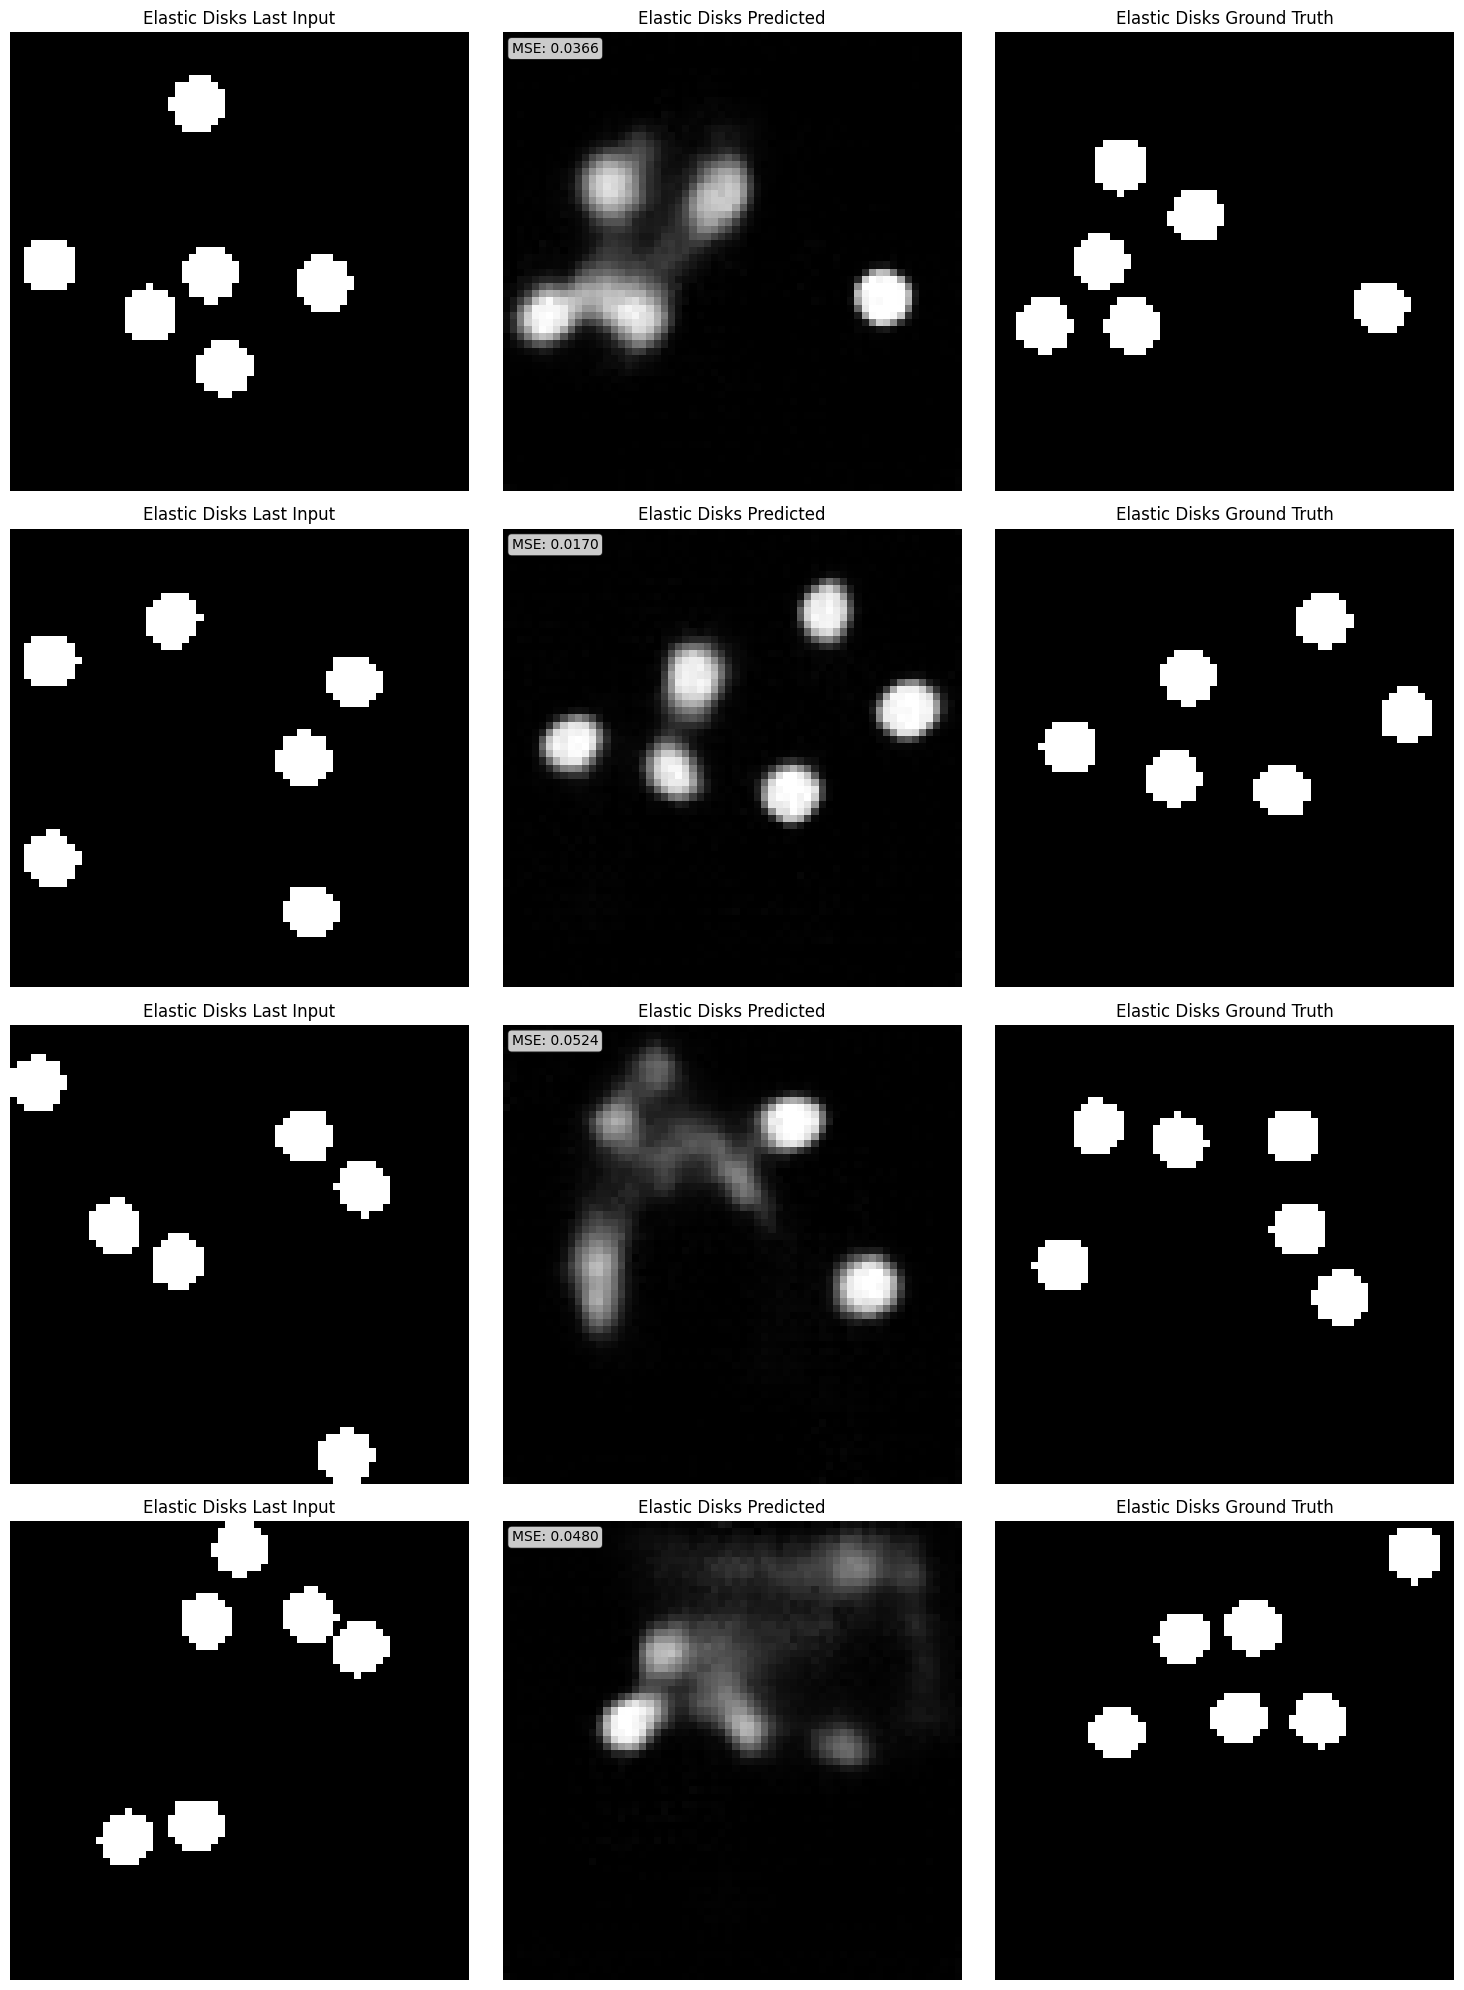

Rollout movie saved to: /content/generative-video-forecasting/outputs/train_elastic_disks_simvp/output_mp4s/elastic_disks_sequence_0_simvp_rollout.mp4


In [6]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

visualize_simvp_predictions(
    model,
    test_dataset,
    num_samples=4,
    device=device,
    title_prefix="Elastic Disks ",
)

test_sequence_idx = 0
test_sequence = test_base.sequences[test_sequence_idx]
rollout_path = generate_simvp_rollout_movie(
    model,
    sequence=test_sequence,
    context_frames=context_frames,
    num_predictions=12,
    start_frame=0,
    dataset_type="elastic_disks",
    device=device,
    fps=10,
    output_dir=str(OUTPUT_DIR / "output_mp4s"),
)
print(f"Rollout movie saved to: {rollout_path}")
display_video(rollout_path)


In [ ]:
# # Backup: mount Google Drive and copy this repo checkout into My Drive (Google Colab only).
# try:
#     from google.colab import drive as colab_drive
# except ImportError:
#     colab_drive = None

# if colab_drive is None:
#     print("Skipping: not running in Google Colab (google.colab not available).")
# else:
#     import shutil
#     from pathlib import Path

#     colab_drive.mount("/content/drive")
#     dest = Path("/content/drive/MyDrive") / "generative-video-forecasting"
#     if dest.exists():
#         shutil.rmtree(dest)
#     shutil.copytree(REPO_ROOT, dest)
#     print(f"Copied repository to {dest}")


Mounted at /content/drive
Copied repository to /content/drive/MyDrive/generative-video-forecasting
